<h2><font color="#004D7F" size=6>Módulo 3. Machine Learning</font></h2>

<h1><font color="#004D7F" size=5>1. Regresión Logistica </font></h1>

<h1><font color="#004D7F" size=5>2. Taller de  Social Network </font></h1>
<br>
<div style="text-align: right">
<font color="#004D7F" size=3>Seminario en Ciencia de Datos</font><br>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Cargar el set de datos
dataset= pd.read_csv("Social_Network_Ads.csv")
dataset.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
# Dividir los datos en entrenamiento y datos de prueba
x = dataset.iloc[:,[2,3]].values # X es la variable independiente contine edad y salario
y = dataset.iloc[:,4].values

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=0)
# 25 % de los datos de entrada se usan para probar el modelo
# 75 % de los datos se usan para el entrenamiento del modelo


In [7]:
# escalacion de datos
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [8]:
#Crear el modelo de regresion logística
from sklearn.linear_model import LogisticRegression
clasificator = LogisticRegression(random_state=0) #recibe random_state=0
clasificator.fit(x_train, y_train) 

LogisticRegression(random_state=0)

In [9]:
# usamos los datos de pruebas
y_pred = clasificator.predict(x_test)

In [10]:
from sklearn.metrics import confusion_matrix
cm =confusion_matrix(y_test,y_pred)
cm

array([[65,  3],
       [ 8, 24]], dtype=int64)

In [11]:
score = clasificator.score(x_test_y_test)
score

0.89

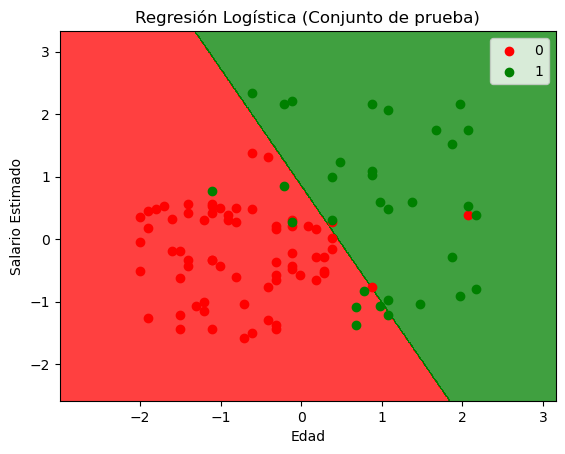

In [13]:
#Visualización de los resultados de prueba
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# Asegúrate de que X_test e y_test están definidos
X_set, y_set = x_test, y_test

# Crear una malla de puntos
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

# Predicción sobre la malla de puntos
Z = clasificator.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

# Dibujar el área de decisión
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))

# Limitar los ejes
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Graficar los puntos de datos
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c=[ListedColormap(('red', 'green'))(i)], label=j
    )

# Etiquetas y título
plt.title("Regresión Logística (Conjunto de prueba)")
plt.xlabel('Edad')
plt.ylabel('Salario Estimado')
plt.legend()
plt.show()